# Existing-data zeroth pilot — pipeline

This notebook is the canonical pipeline for issue #6. It produces:

1. Gait-cycle segmentation (per-trial × side summary table)
2. Feature table per `analysis/features.md`
3. Time-normalized joint-angle traces (hip / knee / ankle, L/R overlay)
4. Speed / condition comparisons
5. OpenCap-vs-reference comparison stats

The notebook re-runs end-to-end against:
- **Real data** when `<GAIT_DATA_ROOT>/opencap-lab-validation/extracted/` is populated (default `GAIT_DATA_ROOT=/opt/gait-data/`; see `data/external/opencap-lab-validation.md` §Acquisition procedure and `notebooks/README.md` §Overriding the data root).
- **Synthetic data** otherwise — a smoke-test of pipeline shape using `scripts.io_opencap.synthesize_trial()`. The smoke-test produces real figures and a feature table but the support-path inference from synthetic data is *not* a valid empirical claim.

**Active design constraints** (from issue #6):
- Boring first: no clustering, no UMAP, no dim-reduction this cycle.
- No raw participant data committed.
- Each numerical claim in the notebook traces to a cell that produced it.

**Reproducibility (AC5):** dependencies pinned in `requirements.txt`; notebook re-runs against the manifest-described local data path with no manual edits. The data root is overridable via the `GAIT_DATA_ROOT` environment variable (default `/opt/gait-data/`).


In [1]:
# Configuration
%matplotlib inline
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = Path(os.getcwd()).resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

# Data root resolution: GAIT_DATA_ROOT env var overrides the documented
# default `/opt/gait-data/`. See notebooks/README.md §Overriding the data
# root. The helpers live in scripts/io_opencap.py so calling code that
# imports the module directly gets the same override behavior.
from scripts.io_opencap import (
    DEFAULT_DATA_ROOT, GAIT_DATA_ROOT_ENV,
    get_data_root, get_opencap_extracted_root,
)

DATA_ROOT = get_data_root()
DATA_PATH = get_opencap_extracted_root()
USE_REAL_DATA = DATA_PATH.exists() and any(DATA_PATH.iterdir())

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}  (default {DEFAULT_DATA_ROOT}; override env {GAIT_DATA_ROOT_ENV})")
print(f"DATA_PATH: {DATA_PATH}  (exists: {DATA_PATH.exists()})")
print(f"USE_REAL_DATA: {USE_REAL_DATA}")


REPO_ROOT: /root/gait-support-paths/.claude/worktrees/opencap-acquisition-manifest
DATA_ROOT: /opt/gait-data  (default /opt/gait-data; override env GAIT_DATA_ROOT)
DATA_PATH: /opt/gait-data/opencap-lab-validation/extracted  (exists: True)
USE_REAL_DATA: True


## 1. Discover trials

In [2]:
from scripts.io_opencap import (
    discover_walking_ik, load_paired_trial, load_all_walking_trials,
    synthesize_trial, IK_SOURCES, Trial,
)

# Primary trial list = Mocap-IK (lab gold standard) with Mocap heel
# markers merged in. This drives segmentation, feature extraction, and
# all plots. The three Video IK sources are loaded separately in §5 for
# the OpenCap-vs-reference comparison.
trials: list[Trial] = []
if USE_REAL_DATA:
    trials = load_all_walking_trials(DATA_PATH, ik_source="Mocap")
    print(f"Found {len(trials)} walking trials from Mocap IK under {DATA_PATH}")
    if not trials:
        raise RuntimeError(
            "USE_REAL_DATA was true but no walking trials discovered — "
            "check that the archive is extracted at "
            f"{DATA_PATH}/LabValidation_withoutVideos/subject*/OpenSimData/Mocap/IK/walking*.mot")
else:
    print("No real data found — synthesizing 4 trials for smoke test")
    trials.append(synthesize_trial(subject="Synth01", trial_id="walking1", condition="walking", n_cycles=8))
    trials.append(synthesize_trial(subject="Synth01", trial_id="walking2", condition="walking", n_cycles=8,
                                   rng=np.random.default_rng(43)))
    trials.append(synthesize_trial(subject="Synth01", trial_id="walkingTS1", condition="walkingTS", n_cycles=7,
                                   rng=np.random.default_rng(44), left_right_asymmetry_deg=3.0))
    trials.append(synthesize_trial(subject="Synth02", trial_id="walking1", condition="walking", n_cycles=9,
                                   rng=np.random.default_rng(45)))

print(f"Total trials: {len(trials)}")
# Compact summary instead of one row per trial when the count is large
if len(trials) <= 12:
    for t in trials:
        print(f"  subject={t.subject}  trial={t.trial_id}  condition={t.condition}  n_samples={len(t.df)}  fs={t.sample_rate_hz:.1f} Hz")
else:
    by_cond = pd.Series([t.condition for t in trials]).value_counts()
    by_sub = pd.Series([t.subject for t in trials]).value_counts().sort_index()
    print(f"  by condition: {dict(by_cond)}")
    print(f"  subjects: {len(by_sub)}  (trials per subject: min={by_sub.min()} max={by_sub.max()} mean={by_sub.mean():.1f})")
    print(f"  sample-rate range: {min(t.sample_rate_hz for t in trials):.1f}-{max(t.sample_rate_hz for t in trials):.1f} Hz")
    print(f"  rows per trial: min={min(len(t.df) for t in trials)} max={max(len(t.df) for t in trials)} mean={int(np.mean([len(t.df) for t in trials]))}")


Found 60 walking trials from Mocap IK under /opt/gait-data/opencap-lab-validation/extracted
Total trials: 60
  by condition: {'walking': np.int64(30), 'walkingTS': np.int64(30)}
  subjects: 10  (trials per subject: min=6 max=6 mean=6.0)
  sample-rate range: 100.0-100.0 Hz
  rows per trial: min=121 max=197 mean=145


## 2. Gait-cycle segmentation (AC1)

In [3]:
from scripts.segmentation import segment_trial, summary_table

all_cycles = []
for trial in trials:
    cycles = segment_trial(trial.df, trial.subject, trial.trial_id, trial.condition, trial.sample_rate_hz)
    all_cycles.extend(cycles)
    print(f"  {trial.subject}/{trial.trial_id}/{trial.condition}: {len(cycles)} cycles ({sum(1 for c in cycles if c.side=='R')} R, {sum(1 for c in cycles if c.side=='L')} L)")

seg_summary = summary_table(all_cycles)
seg_summary


  subject10/walking1/walking: 0 cycles (0 R, 0 L)
  subject10/walking2/walking: 0 cycles (0 R, 0 L)
  subject10/walking3/walking: 1 cycles (1 R, 0 L)
  subject10/walkingTS1/walkingTS: 0 cycles (0 R, 0 L)
  subject10/walkingTS2/walkingTS: 0 cycles (0 R, 0 L)
  subject10/walkingTS3/walkingTS: 0 cycles (0 R, 0 L)
  subject11/walking2/walking: 0 cycles (0 R, 0 L)
  subject11/walking3/walking: 0 cycles (0 R, 0 L)
  subject11/walking4/walking: 0 cycles (0 R, 0 L)
  subject11/walkingTS1/walkingTS: 0 cycles (0 R, 0 L)
  subject11/walkingTS2/walkingTS: 0 cycles (0 R, 0 L)
  subject11/walkingTS3/walkingTS: 0 cycles (0 R, 0 L)
  subject2/walking1/walking: 0 cycles (0 R, 0 L)
  subject2/walking2/walking: 0 cycles (0 R, 0 L)
  subject2/walking3/walking: 0 cycles (0 R, 0 L)
  subject2/walkingTS1/walkingTS: 0 cycles (0 R, 0 L)
  subject2/walkingTS2/walkingTS: 0 cycles (0 R, 0 L)
  subject2/walkingTS4/walkingTS: 0 cycles (0 R, 0 L)
  subject3/walking1/walking: 0 cycles (0 R, 0 L)
  subject3/walking2/w

,subject,trial_id,condition,side,n_cycles,mean_duration_s,n_quality_fail
0,subject10,walking3,walking,R,1,1.01,0
1,subject5,walkingTS3,walkingTS,R,1,1.12,0
2,subject7,walking1,walking,R,1,1.04,0
3,subject7,walking2,walking,R,1,1.27,0
4,subject7,walking3,walking,R,1,1.07,0
5,subject8,walking2,walking,R,1,1.04,0
6,subject8,walking3,walking,R,1,1.08,0
7,subject8,walkingTS1,walkingTS,R,1,1.34,0
8,subject8,walkingTS3,walkingTS,R,1,1.24,0
9,subject9,walking1,walking,R,1,1.06,0


In [4]:
# AC1 oracle: ≥80% of walking trials yielded ≥1 cycle.
n_walking_trials = sum(1 for t in trials if 'walk' in t.condition.lower())
trials_with_cycles = seg_summary.groupby(['subject', 'trial_id', 'condition']).size().shape[0] if len(seg_summary) else 0
seg_rate = trials_with_cycles / max(n_walking_trials, 1) * 100.0
print(f"Walking trials: {n_walking_trials}")
print(f"Trials with ≥1 cycle: {trials_with_cycles}")
print(f"Segmentation rate: {seg_rate:.1f}%   (GO ≥80%, NO-GO <60%)")


Walking trials: 60
Trials with ≥1 cycle: 11
Segmentation rate: 18.3%   (GO ≥80%, NO-GO <60%)


## 3. Feature table (AC2)

In [5]:
from scripts.features import build_feature_table, missingness

features = build_feature_table(all_cycles)
print(f"Feature table shape: {features.shape}")
features.head(8)


Feature table shape: (11, 29)


,subject,session,trial_id,condition,side,cycle_number,quality_flag,exclusion_flag,cycle_duration_s,stance_duration_s,...,knee_angle_min_deg,ankle_angle_range_deg,ankle_angle_peak_deg,ankle_angle_min_deg,pelvis_tilt_range_deg,pelvis_list_range_deg,pelvis_rotation_range_deg,normalized_curve_available,hip_knee_lag_samples,hip_knee_lag_pct_cycle
0,subject10,S01,walking3,walking,R,1,ok,False,1.01,0.56,...,4.207530,33.512970,20.231827,-13.281143,5.154768,9.467653,16.821445,True,13,12.871287
1,subject5,S01,walkingTS3,walkingTS,R,1,ok,False,1.12,0.57,...,0.606162,23.938509,20.623973,-3.314536,4.877347,6.813092,9.421022,True,17,15.178571
2,subject7,S01,walking1,walking,R,1,ok,False,1.04,0.55,...,1.643648,33.080564,19.234270,-13.846294,2.367264,10.476054,16.469551,True,14,13.461538
3,subject7,S01,walking2,walking,R,1,ok,False,1.27,0.55,...,1.913658,35.147104,19.954520,-15.192584,2.994736,11.442954,15.206599,True,19,14.960630
4,subject7,S01,walking3,walking,R,1,ok,False,1.07,0.56,...,1.925853,33.426959,20.782874,-12.644085,2.576785,9.594763,18.317481,True,15,14.018692
5,subject8,S01,walking2,walking,R,1,ok,False,1.04,0.56,...,6.334007,35.507913,13.267424,-22.240489,2.566161,6.509333,12.965641,True,13,12.500000
6,subject8,S01,walking3,walking,R,1,ok,False,1.08,0.57,...,7.855378,33.247800,14.808056,-18.439744,2.636981,7.013768,15.440948,True,14,12.962963
7,subject8,S01,walkingTS1,walkingTS,R,1,ok,False,1.34,0.70,...,9.094623,31.508246,15.174641,-16.333605,5.359249,9.186561,23.312390,True,19,14.179104


In [6]:
miss = missingness(features)
miss


,column,null_count,null_pct
0,subject,0,0.0
1,session,0,0.0
2,trial_id,0,0.0
3,condition,0,0.0
4,side,0,0.0
5,cycle_number,0,0.0
6,quality_flag,0,0.0
7,exclusion_flag,0,0.0
8,cycle_duration_s,0,0.0
9,stance_duration_s,0,0.0


In [7]:
# AC2 oracle: missingness < 20% across feature columns
overall_miss = miss['null_pct'].mean()
print(f"Mean missingness across feature columns: {overall_miss:.2f}%  (target <20%)")


Mean missingness across feature columns: 0.00%  (target <20%)


## 4. First-pass plots (AC3)

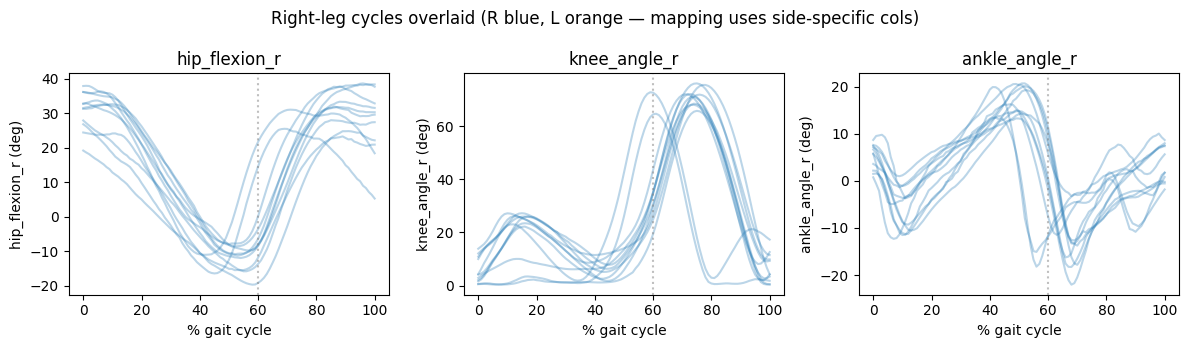

In [8]:
from scripts.segmentation import time_normalize_cycle

def overlay_cycles(cycles, columns, title):
    fig, axes = plt.subplots(1, len(columns), figsize=(4*len(columns), 3.5), sharex=True)
    if len(columns) == 1:
        axes = [axes]
    side_color = {"R": "tab:blue", "L": "tab:orange"}
    for col, ax in zip(columns, axes):
        for c in cycles:
            norm = time_normalize_cycle(c, columns=[col])
            if not norm.empty:
                ax.plot(norm["phase_pct"], norm[col], color=side_color.get(c.side, "k"), alpha=0.3)
        ax.set_xlabel("% gait cycle")
        ax.set_ylabel(f"{col} (deg)")
        ax.set_title(col)
        ax.axvline(60, color='gray', ls=':', alpha=0.5, label='toe-off (typical)')
    fig.suptitle(title)
    plt.tight_layout()
    return fig

r_cycles = [c for c in all_cycles if c.side == "R" and c.quality_flag == "ok"]
l_cycles = [c for c in all_cycles if c.side == "L" and c.quality_flag == "ok"]

fig = overlay_cycles(r_cycles + l_cycles,
                     ["hip_flexion_r", "knee_angle_r", "ankle_angle_r"],
                     "Right-leg cycles overlaid (R blue, L orange — mapping uses side-specific cols)")
plt.show()


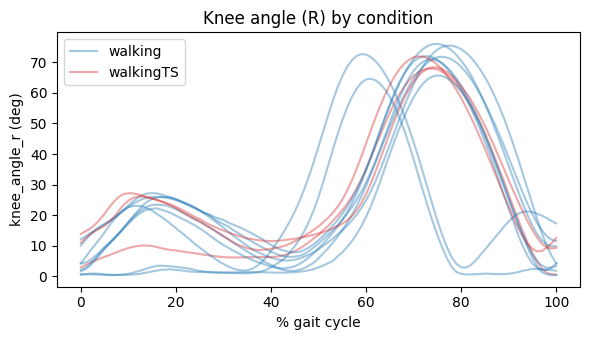

In [9]:
# Condition comparison: walking vs walkingTS
def by_condition_plot(cycles, joint_col, title):
    cond_color = {"walking": "tab:blue", "walkingTS": "tab:red"}
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for c in cycles:
        if c.side != "R":
            continue
        norm = time_normalize_cycle(c, columns=[joint_col])
        if not norm.empty:
            ax.plot(norm["phase_pct"], norm[joint_col],
                    color=cond_color.get(c.condition, "k"), alpha=0.4,
                    label=c.condition if c.cycle_number == 1 else "")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    ax.set_xlabel("% gait cycle")
    ax.set_ylabel(f"{joint_col} (deg)")
    ax.set_title(title)
    plt.tight_layout()
    return fig

fig = by_condition_plot(all_cycles, "knee_angle_r", "Knee angle (R) by condition")
plt.show()


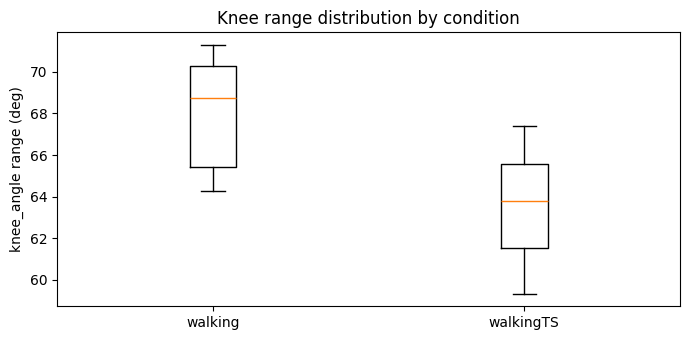

In [10]:
# Feature distribution: knee range across cycles
fig, ax = plt.subplots(figsize=(7, 3.5))
if "knee_angle_range_deg" in features.columns:
    by_cond = {cond: features.loc[features["condition"] == cond, "knee_angle_range_deg"].dropna()
               for cond in features["condition"].unique()}
    ax.boxplot(by_cond.values(), tick_labels=list(by_cond.keys()))
    ax.set_ylabel("knee_angle range (deg)")
    ax.set_title("Knee range distribution by condition")
plt.tight_layout()
plt.show()


## 5. OpenCap-vs-reference comparison (AC4)

In [11]:
from scripts.comparison import compare_joints

# Joints compared across IK sources. These are the OpenSim coordinate
# names used in both Mocap IK and Video IK output files; the IK pipeline
# scales the same generic model in both cases, so column names match.
COMPARISON_JOINTS = [
    "hip_flexion_r", "hip_flexion_l",
    "knee_angle_r", "knee_angle_l",
    "ankle_angle_r", "ankle_angle_l",
]

VIDEO_SOURCES = [s for s in IK_SOURCES if s != "Mocap"]

if USE_REAL_DATA:
    # For each Video IK source, pair against the Mocap IK from the same
    # trial (matched by subject + trial_id) and compute per-joint RMSE,
    # pearson r, and mean bias. Aggregate across trials per (source, joint).
    mocap_index = {(t.subject, t.trial_id): t for t in trials}
    rows = []
    for src in VIDEO_SOURCES:
        video_trials = load_all_walking_trials(DATA_PATH, ik_source=src)
        for vt in video_trials:
            mt = mocap_index.get((vt.subject, vt.trial_id))
            if mt is None:
                continue
            per_joint = compare_joints(vt.df, mt.df, joints=COMPARISON_JOINTS)
            per_joint["source"] = src
            per_joint["subject"] = vt.subject
            per_joint["trial_id"] = vt.trial_id
            per_joint["condition"] = vt.condition
            rows.append(per_joint)
    per_trial = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    print(f"Paired comparisons: {len(per_trial)} rows ({len(VIDEO_SOURCES)} sources × ~{len(trials)} trials × {len(COMPARISON_JOINTS)} joints)")

    # Aggregate: mean ± std RMSE / pearson r / bias per (source, joint).
    if len(per_trial):
        comparison = (per_trial
                      .groupby(["source", "joint"], as_index=False)
                      .agg(rmse_deg_mean=("rmse_deg", "mean"),
                           rmse_deg_std=("rmse_deg", "std"),
                           pearson_r_mean=("pearson_r", "mean"),
                           pearson_r_std=("pearson_r", "std"),
                           bias_deg_mean=("mean_bias_deg", "mean"),
                           n_trials=("rmse_deg", "count")))
    else:
        comparison = pd.DataFrame()
else:
    # Smoke: compare a synthetic trial against itself + noise to verify the function shape.
    rng = np.random.default_rng(99)
    base = trials[0].df.copy()
    noisy = base.copy()
    for col in ["hip_flexion_r", "knee_angle_r", "ankle_angle_r"]:
        noisy[col] = noisy[col] + rng.normal(0, 1.5, len(noisy))
    comparison = compare_joints(noisy, base, joints=["hip_flexion_r", "knee_angle_r", "ankle_angle_r"])
    per_trial = pd.DataFrame()
    print("Smoke comparison (synthetic vs synthetic+noise):")
comparison


Paired comparisons: 1080 rows (3 sources × ~60 trials × 6 joints)


,source,joint,rmse_deg_mean,rmse_deg_std,pearson_r_mean,pearson_r_std,bias_deg_mean,n_trials
0,HRNet_5cam,ankle_angle_l,6.060025,1.622251,0.941313,0.029770,4.841123,60
1,HRNet_5cam,ankle_angle_r,5.202147,1.760716,0.905366,0.056729,3.031308,60
2,HRNet_5cam,hip_flexion_l,6.218042,2.827930,0.974546,0.016708,1.429850,60
3,HRNet_5cam,hip_flexion_r,5.355399,3.097504,0.984448,0.010695,1.252367,60
4,HRNet_5cam,knee_angle_l,4.754834,1.484370,0.985811,0.010675,0.654864,60
5,HRNet_5cam,knee_angle_r,4.669691,1.984322,0.982694,0.012894,-0.105470,60
6,OpenPose_default_5cam,ankle_angle_l,6.372297,1.617850,0.881844,0.091619,3.478945,60
7,OpenPose_default_5cam,ankle_angle_r,5.048504,1.377809,0.860612,0.074723,2.200255,60
8,OpenPose_default_5cam,hip_flexion_l,7.190156,2.415554,0.946685,0.037751,1.214007,60
9,OpenPose_default_5cam,hip_flexion_r,6.335833,2.576297,0.970158,0.018472,1.359620,60


In [12]:
# AC4 oracle: per-source mean Pearson r ≥ 0.7 across knee+hip+ankle.
# (RMSE and bias are reported but no fixed threshold — the paper itself
# documents RMSE ~3-8° as the typical OpenCap-vs-mocap range, so we
# surface the numbers and let the reader judge.)
if USE_REAL_DATA and len(comparison):
    overall_r = comparison.groupby("source")["pearson_r_mean"].mean()
    print("Mean Pearson r across joints, per source:")
    for src, r in overall_r.items():
        print(f"  {src:32s} : r̄ = {r:.3f}  (GO ≥ 0.7)")


Mean Pearson r across joints, per source:
  HRNet_5cam                       : r̄ = 0.962  (GO ≥ 0.7)
  OpenPose_default_5cam            : r̄ = 0.933  (GO ≥ 0.7)
  OpenPose_highAccuracy_5cam       : r̄ = 0.951  (GO ≥ 0.7)


## 6. Persist feature table (private — not committed)

In [13]:
PRIVATE_OUT = DATA_ROOT / "gait-support-paths-features"
PRIVATE_OUT.mkdir(parents=True, exist_ok=True)

feature_path = PRIVATE_OUT / "features-zeroth-pilot.parquet"
try:
    features.to_parquet(feature_path, index=False)
    print(f"Feature table written to {feature_path}")
except ImportError:
    # pyarrow not available — fall back to CSV but still outside the repo
    feature_path = PRIVATE_OUT / "features-zeroth-pilot.csv"
    features.to_csv(feature_path, index=False)
    print(f"pyarrow unavailable; wrote CSV instead: {feature_path}")

# Aggregate summary IS committed (small, anonymized). This file is the
# durable evidence artifact that the field report cites — it must carry
# enough numbers to stand on its own, not just a row count.
import datetime as _dt
summary_path = REPO_ROOT / "analysis" / "feature-summary-zeroth-pilot.md"

n_walking_trials_total = sum(1 for t in trials if 'walk' in t.condition.lower())
n_subjects_in_archive = len({t.subject for t in trials})
n_cycles_total = len(all_cycles)
n_cycles_R = sum(1 for c in all_cycles if c.side == 'R')
n_cycles_L = sum(1 for c in all_cycles if c.side == 'L')
n_trials_with_cycles = (seg_summary.groupby(['subject', 'trial_id', 'condition']).size().shape[0]
                        if len(seg_summary) else 0)
seg_rate = 100.0 * n_trials_with_cycles / max(n_walking_trials_total, 1)
ac1_status = 'PASS' if seg_rate >= 80 else ('FAIL (NO-GO)' if seg_rate < 60 else 'PARTIAL (REVISE)')

n_features_rows = len(features)
mean_missing = miss['null_pct'].mean() if len(features) else float('nan')
ac2_status = 'PASS' if mean_missing < 20 else 'FAIL'

mode_label = 'real-data' if USE_REAL_DATA else 'synthetic-smoke'
run_ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%SZ')

# AC4 comparison summary (real-data only — smoke skips this section)
ac4_lines = []
if USE_REAL_DATA and len(comparison):
    overall_r = comparison.groupby('source')['pearson_r_mean'].mean()
    overall_rmse = comparison.groupby('source')['rmse_deg_mean'].mean()
    n_trials_compared = int(comparison['n_trials'].max())
    ac4_lines.append(f"- compared trials per source: {n_trials_compared}")
    ac4_pass_all = all(r >= 0.7 for r in overall_r.values)
    ac4_lines.append(f"- AC4 oracle (r̄ ≥ 0.7 per source): {'PASS (all sources)' if ac4_pass_all else 'FAIL'}")
    for src in overall_r.index:
        ac4_lines.append(f"  - {src}: r̄ = {overall_r[src]:.3f}, RMSĒ = {overall_rmse[src]:.2f}°")
elif USE_REAL_DATA:
    ac4_lines.append("- AC4 comparison: no comparison rows produced (check Video IK discovery)")
else:
    ac4_lines.append("- AC4 comparison: skipped (synthetic-smoke mode)")

lines = [
    "# Feature Summary (auto-generated by notebook §6)",
    "",
    f"- last run: {run_ts}",
    f"- mode: {mode_label}",
    f"- walking trials discovered: {n_walking_trials_total}",
    f"- subjects in archive: {n_subjects_in_archive}",
    "",
    "## AC1 — Gait-cycle segmentation",
    f"- trials with ≥1 cycle: {n_trials_with_cycles} / {n_walking_trials_total} ({seg_rate:.1f}%)",
    f"- cycles total: {n_cycles_total}  (R: {n_cycles_R}, L: {n_cycles_L})",
    f"- AC1 oracle (≥80% trials with cycles): {ac1_status}",
    "",
    "## AC2 — Feature missingness",
    f"- feature-table rows (one per cycle): {n_features_rows}",
    f"- mean missingness across columns: {mean_missing:.2f}%",
    f"- AC2 oracle (<20% missingness): {ac2_status}",
    "",
    "## AC4 — OpenCap-vs-reference comparison",
] + ac4_lines + [
    "",
    "## Provenance",
    "- archive: `LabValidation_withoutVideos.zip`, SHA-256 `3290d485124fd12c85dd3bc9ee851f3a0530ad0ff58bc396973e665dd6d28187` (see `data/external/opencap-lab-validation.md`).",
    "- per-cycle features csv lives at `$GAIT_DATA_ROOT/gait-support-paths-features/features-zeroth-pilot.csv` (outside repo).",
    "- regenerate this file by running `python3 scripts/build_notebook.py && jupyter nbconvert --execute --inplace notebooks/existing-data-processing.ipynb`.",
    "",
]
summary_path.write_text("\n".join(lines) + "\n")
print(f"Aggregate summary written to {summary_path}")


pyarrow unavailable; wrote CSV instead: /opt/gait-data/gait-support-paths-features/features-zeroth-pilot.csv
Aggregate summary written to /root/gait-support-paths/.claude/worktrees/opencap-acquisition-manifest/analysis/feature-summary-zeroth-pilot.md


## 7. Notebook self-check

Maps notebook outputs to issue #6 ACs:

- **AC1** — Gait-cycle segmentation ≥80%: printed in cell §2 with explicit threshold.
- **AC2** — Feature table + missingness <20%: printed in cell §3 with explicit threshold.
- **AC3** — First-pass plots (time-normalized hip/knee/ankle, L/R overlay, speed/condition comparisons, feature distributions): cells in §4.
- **AC4** — OpenCap-vs-reference comparison: cell §5. Real-data implementation pairs Mocap IK against each of HRNet / OpenPose_default / OpenPose_highAccuracy at the 5-cameras setup; per-trial table is in `per_trial`, aggregate is in `comparison`. Smoke mode still exercises `compare_joints` against synthetic noise.
- **AC5** — Reproducibility: dependencies pinned in `../requirements.txt`; this notebook re-runs end-to-end against `<GAIT_DATA_ROOT>/opencap-lab-validation/extracted/` (default `GAIT_DATA_ROOT=/opt/gait-data/`) when populated.

**Known debt (carried into Sub C):**

- The feature table omits some `analysis/features.md` features (asymmetry shape-correlation, condition-response deltas) — they require multi-trial aggregation that lives in Sub C's analysis, not Sub B's per-cycle extraction.
- Hip ab/ad-duction features are not yet in `scripts/features.py::extract_range`; needed for Hypothesis 2's frontal-plane comparison. Trivial extension once a column-naming convention is fixed; queued for a later cycle per the operator-confirmed minimal-adaptation scope.
